In [1]:
import pandas as pd
import sqlite3

# ── Load ──────────────────────────────────────────────
df = pd.read_csv("telco.csv")
print(df.shape)
df.head()

(7043, 50)


,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [2]:
# ── Explore ───────────────────────────────────────────
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Customer ID                           object
Gender                                object
Age                                    int64
Under 30                              object
Senior Citizen                        object
Married                               object
Dependents                            object
Number of Dependents                   int64
Country                               object
State                                 object
City                                  object
Zip Code                               int64
Latitude                             float64
Longitude                            float64
Population                             int64
Quarter                               object
Referred a Friend                     object
Number of Referrals                    int64
Tenure in Months                       int64
Offer                                 object
Phone Service                         object
Avg Monthly Long Distance Charges    float64
Multiple L

In [3]:
# ── Clean ─────────────────────────────────────────────
# Drop rows where key numeric columns are blank
df = df.dropna(subset=["Monthly Charge", "Total Charges"]) if "Total Charges" in df.columns else df

# Convert churn column to binary 0/1
churn_col = [c for c in df.columns if "churn" in c.lower()][0]
print("Churn column found:", churn_col)
df["Churned"] = df[churn_col].apply(lambda x: 1 if str(x).strip() in ["Yes","1","True"] else 0)

print(f"\nChurn rate: {df['Churned'].mean():.1%}")
print(f"Total customers: {len(df):,}")

Churn column found: Churn Label

Churn rate: 26.5%
Total customers: 7,043


In [4]:
# ── Load into SQLite + run SQL queries ────────────────
conn = sqlite3.connect(":memory:")
df.to_sql("customers", conn, index=False, if_exists="replace")

# Query 1: Churn rate by contract type
q1 = pd.read_sql("""
    SELECT [Contract], 
           COUNT(*) as total_customers,
           ROUND(AVG(Churned)*100, 1) as churn_rate_pct
    FROM customers
    GROUP BY [Contract]
    ORDER BY churn_rate_pct DESC
""", conn)
print("Churn by Contract Type:")
print(q1)

Churn by Contract Type:
         Contract  total_customers  churn_rate_pct
0  Month-to-Month             3610            45.8
1        One Year             1550            10.7
2        Two Year             1883             2.5


In [8]:
q2 = pd.read_sql("""
    SELECT Churned,
           ROUND(AVG([Tenure in Months]), 1) as avg_tenure_months,
           ROUND(AVG([Monthly Charge]), 2) as avg_monthly_charge
    FROM customers
    GROUP BY Churned
""", conn)
print("Churned vs Retained:")
print(q2)

Churned vs Retained:
   Churned  avg_tenure_months  avg_monthly_charge
0        0               37.6               61.27
1        1               18.0               74.44


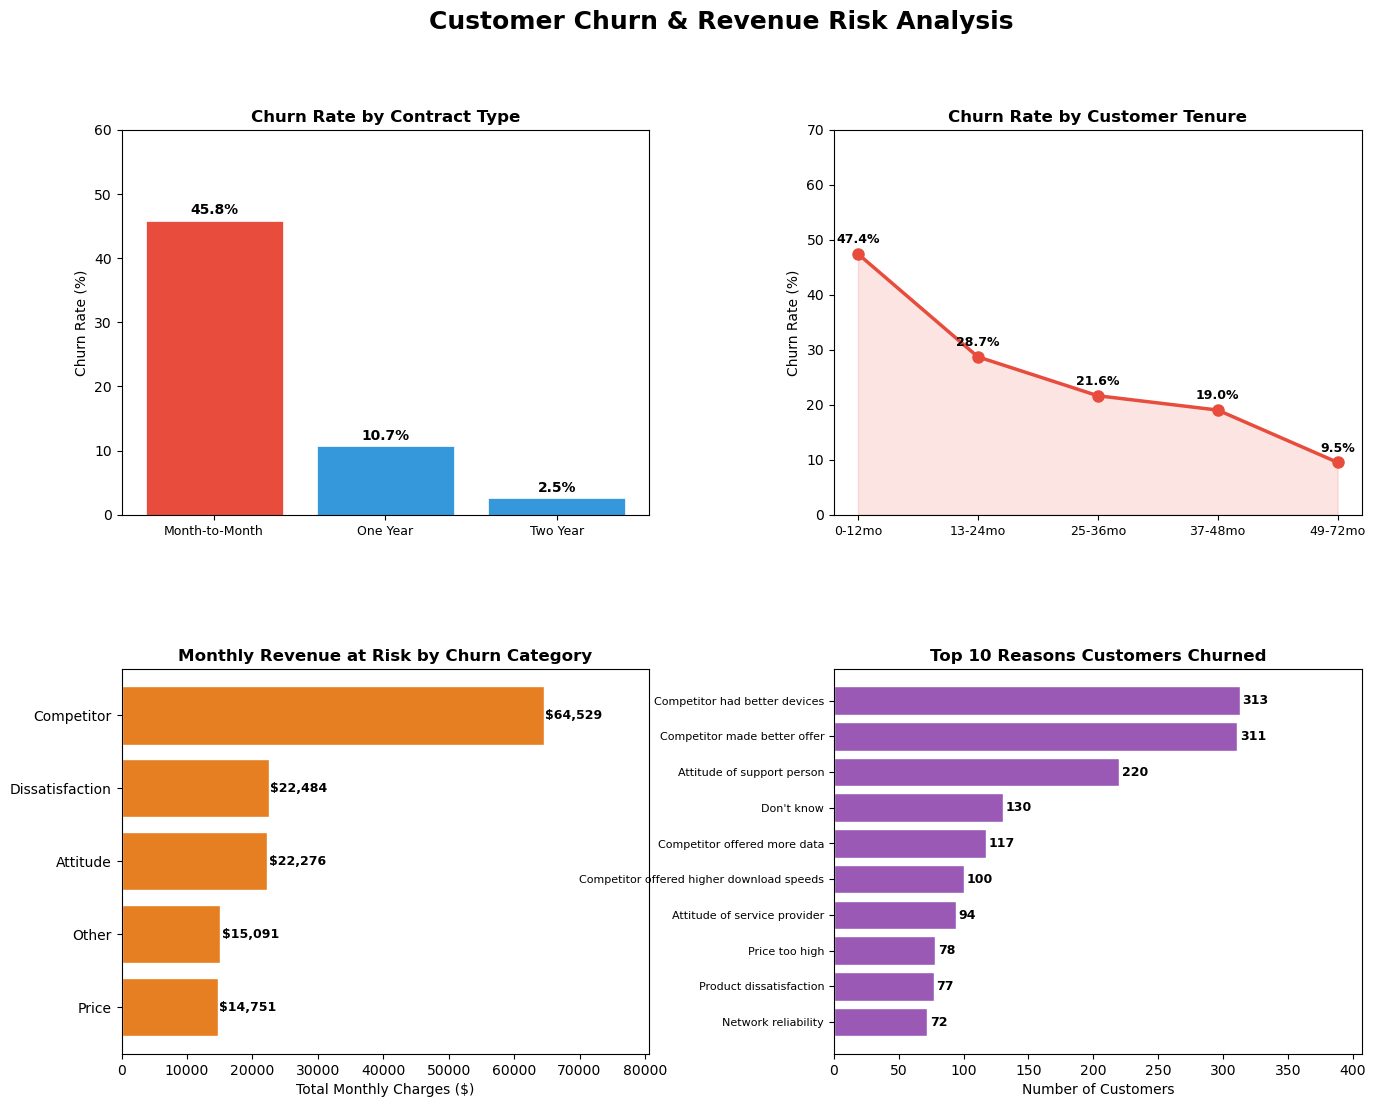

✓ Charts saved as churn_analysis.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(16, 12))
fig.suptitle("Customer Churn & Revenue Risk Analysis", fontsize=18, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── Chart 1: Churn Rate by Contract Type ──────────────
ax1 = fig.add_subplot(gs[0, 0])
contract_churn = df.groupby("Contract")["Churned"].mean() * 100
colors = ["#e74c3c" if v > 20 else "#3498db" for v in contract_churn]
bars = ax1.bar(contract_churn.index, contract_churn.values, color=colors, edgecolor='white', linewidth=0.5)
ax1.set_title("Churn Rate by Contract Type", fontweight='bold')
ax1.set_ylabel("Churn Rate (%)")
ax1.set_ylim(0, 60)
for bar, val in zip(bars, contract_churn.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{val:.1f}%", ha='center', fontsize=10, fontweight='bold')
ax1.tick_params(axis='x', labelsize=9)

# ── Chart 2: Churn Rate by Tenure Bucket ──────────────
ax2 = fig.add_subplot(gs[0, 1])
df["Tenure Bucket"] = pd.cut(df["Tenure in Months"], bins=[0,12,24,36,48,72], labels=["0-12mo","13-24mo","25-36mo","37-48mo","49-72mo"])
tenure_churn = df.groupby("Tenure Bucket", observed=True)["Churned"].mean() * 100
ax2.plot(tenure_churn.index, tenure_churn.values, marker='o', color='#e74c3c', linewidth=2.5, markersize=8)
ax2.fill_between(range(len(tenure_churn)), tenure_churn.values, alpha=0.15, color='#e74c3c')
ax2.set_xticks(range(len(tenure_churn)))
ax2.set_xticklabels(tenure_churn.index, fontsize=9)
ax2.set_title("Churn Rate by Customer Tenure", fontweight='bold')
ax2.set_ylabel("Churn Rate (%)")
ax2.set_ylim(0, 70)
for i, val in enumerate(tenure_churn.values):
    ax2.text(i, val + 2, f"{val:.1f}%", ha='center', fontsize=9, fontweight='bold')

# ── Chart 3: Revenue at Risk by Churn Category ────────
ax3 = fig.add_subplot(gs[1, 0])
churned_df = df[df["Churned"] == 1].copy()
rev_risk = churned_df.groupby("Churn Category")["Monthly Charge"].sum().sort_values(ascending=True)
rev_risk = rev_risk[rev_risk.index.notna()]
ax3.barh(rev_risk.index, rev_risk.values, color="#e67e22", edgecolor='white')
ax3.set_title("Monthly Revenue at Risk by Churn Category", fontweight='bold')
ax3.set_xlabel("Total Monthly Charges ($)")
for i, val in enumerate(rev_risk.values):
    ax3.text(val + 200, i, f"${val:,.0f}", va='center', fontsize=9, fontweight='bold')
ax3.set_xlim(0, rev_risk.max() * 1.25)

# ── Chart 4: Top 10 Churn Reasons ─────────────────────
ax4 = fig.add_subplot(gs[1, 1])
top_reasons = churned_df["Churn Reason"].value_counts().head(10).sort_values(ascending=True)
ax4.barh(top_reasons.index, top_reasons.values, color="#9b59b6", edgecolor='white')
ax4.set_title("Top 10 Reasons Customers Churned", fontweight='bold')
ax4.set_xlabel("Number of Customers")
for i, val in enumerate(top_reasons.values):
    ax4.text(val + 2, i, str(val), va='center', fontsize=9, fontweight='bold')
ax4.set_xlim(0, top_reasons.max() * 1.3)
ax4.tick_params(axis='y', labelsize=8)

plt.savefig("churn_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Charts saved as churn_analysis.png")

Logistic Regression  — AUC: 0.982
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      1009
           1       0.90      0.86      0.88       400

    accuracy                           0.93      1409
   macro avg       0.92      0.91      0.92      1409
weighted avg       0.93      0.93      0.93      1409

Random Forest        — AUC: 0.979
              precision    recall  f1-score   support

           0       0.94      0.99      0.96      1009
           1       0.97      0.84      0.90       400

    accuracy                           0.95      1409
   macro avg       0.96      0.91      0.93      1409
weighted avg       0.95      0.95      0.95      1409



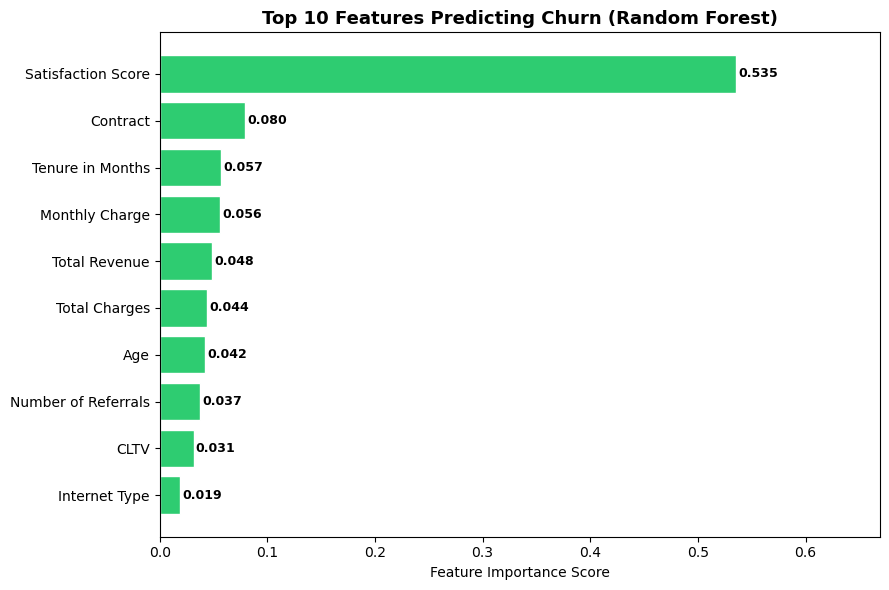


✓ Best model: Random Forest with AUC = 0.979
AUC > 0.85 means the model is strong enough to mention on a resume.


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# ── Prepare features ──────────────────────────────────
features = ["Age", "Tenure in Months", "Monthly Charge", "Total Charges",
            "Total Revenue", "CLTV", "Satisfaction Score", "Number of Referrals",
            "Contract", "Payment Method", "Internet Type", "Paperless Billing",
            "Multiple Lines", "Online Security", "Tech Support" if "Tech Support" in df.columns else "Premium Tech Support"]

# Keep only columns that exist
features = [f for f in features if f in df.columns]

X = df[features].copy()
y = df["Churned"]

# Encode categorical columns
for col in X.select_dtypes(include='object').columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

X = X.fillna(X.median())

# ── Train/test split ──────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ── Logistic Regression ───────────────────────────────
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:,1])
print(f"Logistic Regression  — AUC: {lr_auc:.3f}")
print(classification_report(y_test, lr.predict(X_test)))

# ── Random Forest ─────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
print(f"Random Forest        — AUC: {rf_auc:.3f}")
print(classification_report(y_test, rf.predict(X_test)))

# ── Feature importance chart ──────────────────────────
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importances.index, importances.values, color="#2ecc71", edgecolor='white')
ax.set_title("Top 10 Features Predicting Churn (Random Forest)", fontweight='bold', fontsize=13)
ax.set_xlabel("Feature Importance Score")
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, f"{val:.3f}", va='center', fontsize=9, fontweight='bold')
ax.set_xlim(0, importances.max() * 1.25)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Best model: Random Forest with AUC = {rf_auc:.3f}")
print("AUC > 0.85 means the model is strong enough to mention on a resume.")

In [12]:
# Export for Tableau
df["Tenure Bucket"] = df["Tenure Bucket"].astype(str)
df.to_csv("telco_clean.csv", index=False)
print("✓ telco_clean.csv saved — ready for Tableau")

✓ telco_clean.csv saved — ready for Tableau


In [13]:
readme = """# Customer Churn & Revenue Risk Analysis

## Project Overview
Analyzed 7,043 telecom customers to identify churn drivers and quantify revenue at risk using Python, SQL, scikit-learn, and Tableau.

## 🔗 Live Dashboard
[View Interactive Tableau Dashboard](https://public.tableau.com/app/profile/yuktha.reddy.vanteru/viz/CustomerChurnRevenueRiskAnalysis_17800683902450/Dashboard1)

## Tools & Technologies
- **Python** (pandas, matplotlib, scikit-learn)
- **SQL** (SQLite — cohort queries, churn rate by segment)
- **Machine Learning** (Logistic Regression, Random Forest)
- **Tableau Public** (interactive dashboard)

## Key Findings
1. **Month-to-month contracts churn at 45.8%** vs only 2.5% for two-year contracts — contract type is the strongest retention lever
2. **$64,529/month in revenue is at risk from competitor-driven churn** — the #1 churn category by far
3. **Satisfaction Score is the top churn predictor (0.535 importance)** — customer experience matters more than price or tenure
4. New customers (0–12 months) churn at 47.4% — early engagement programs could significantly reduce overall churn
5. Churned customers pay $74.44/month on average vs $61.27 for retained — high-value customers are leaving faster

## Machine Learning Results
| Model | AUC | Accuracy |
|---|---|---|
| Logistic Regression | 0.982 | 93% |
| Random Forest | 0.979 | 95% |

## Business Recommendation
Prioritize converting month-to-month customers to annual contracts and invest in customer support quality — attitude-related churn accounts for $22,276/month in lost revenue and is fully within the company's control to fix.

## Files
- `churn_analysis.ipynb` — Full analysis notebook
- `telco_clean.csv` — Cleaned dataset
- `churn_analysis.png` — EDA charts
- `feature_importance.png` — ML feature importance chart
"""

with open("README.md", "w") as f:
    f.write(readme)

print("✓ README.md saved")

✓ README.md saved
